In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------------
# Publication settings
# ------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

SCHEMAS = ["Baseline", "6NF", "Status Column"]
COLORS = ["#2563eb", "#d97706", "#16a34a"]

In [2]:
logical_io = {
    "Q1": [2018, 2018, 3310],
    "Q4": [15, 1186, 28],
    "Q5": [1253, 2649, 1811],
    "Q6": [15, 17, 28],
    "Q7": [784, 840, 1467],
}

joins = {
    "Q1": [1, 1, 1],
    "Q4": [0, 5, 0],
    "Q5": [1, 3, 1],
    "Q6": [0, 1, 0],
    "Q7": [1, 2, 1],
}

predicates = {
    "Q1": [2, 2, 2],
    "Q4": [5, 5, 5],
    "Q5": [1, 4, 2],
    "Q6": [0, 1, 4],
    "Q7": [3, 4, 1],
}

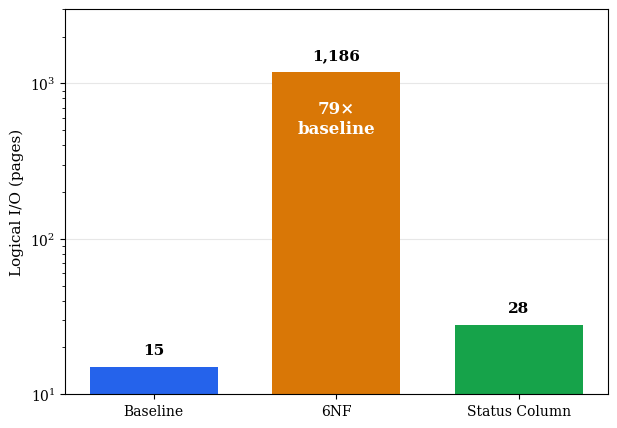

In [3]:
# ------------------------------------------------------------------
# Figure 4 - Q4 Logical I/O (log scale)
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7,5))

vals = logical_io["Q4"]

bars = ax.bar(
    SCHEMAS,
    vals,
    color=COLORS,
    width=0.7
)

ax.set_yscale("log")
ax.set_ylabel("Logical I/O (pages)")

for b, v in zip(bars, vals):
    ax.text(
        b.get_x() + b.get_width()/2,
        v * 1.15,
        f"{v:,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ratio = vals[1] / vals[0]

ax.text(
    1,
    vals[1] / 2,
    f"{ratio:.0f}×\nbaseline",
    ha="center",
    va="center",
    color="white",
    fontweight="bold",
    fontsize=12
)

ax.set_ylim(10, 3000)
ax.grid(True, axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.show()

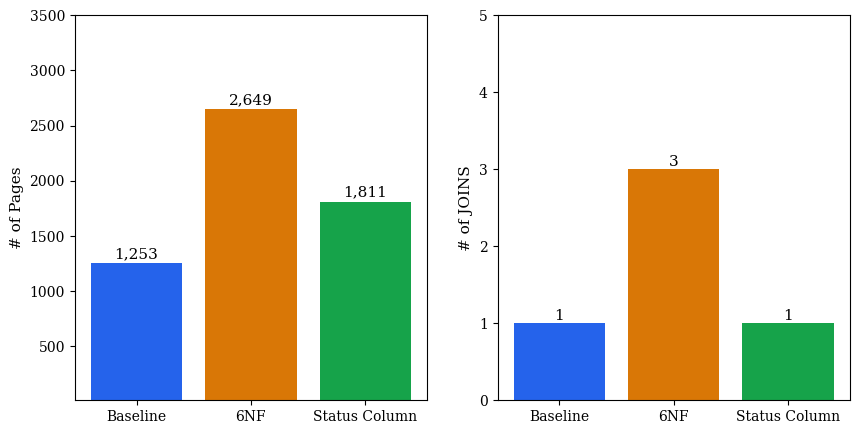

In [6]:
# ------------------------------------------------------------------
# Figure 5 - Q5 comparison
# ------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

# Logical I/O
vals = logical_io["Q5"]

bars = axes[0].bar(
    SCHEMAS,
    vals,
    color=COLORS
)

axes[0].set_ylabel("# of Pages")
axes[1].set_ylabel("# of JOINS")

for b, v in zip(bars, vals):
    axes[0].text(
        b.get_x() + b.get_width()/2,
        v + 50,
        f"{v:,}",
        ha="center"
    )

# Join count
vals = joins["Q5"]

bars = axes[1].bar(
    SCHEMAS,
    vals,
    color=COLORS
)

for b, v in zip(bars, vals):
    axes[1].text(
        b.get_x() + b.get_width()/2,
        v + 0.05,
        str(v),
        ha="center"
    )
axes[0].set_ylim(10, 3500)
axes[1].set_ylim(0, 5)

plt.show()

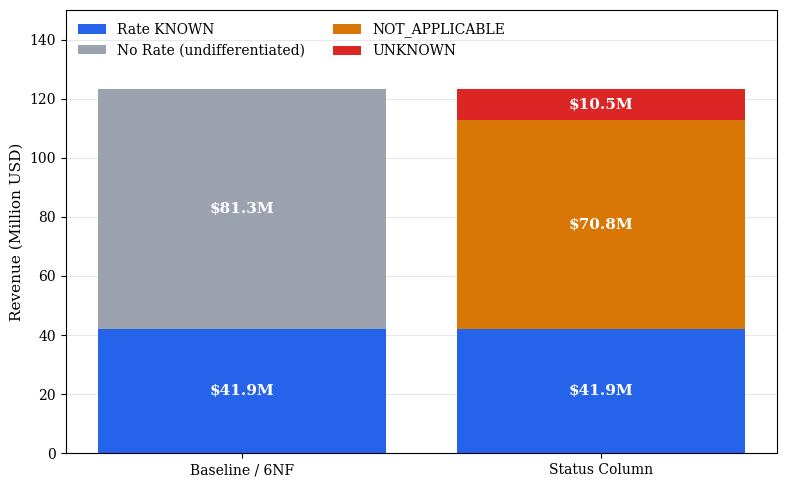

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

# Revenue values (millions USD)
known = 41.9

baseline_no_rate = 81.3

status_not_applicable = 70.8
status_unknown = 10.5

labels = ["Baseline / 6NF", "Status Column"]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(8, 5))

# Colors
known_color = "#2563eb"
no_rate_color = "#9ca3af"
na_color = "#d97706"
unknown_color = "#dc2626"

# ---------------------------------------------------
# Baseline / 6NF
# ---------------------------------------------------

ax.bar(
    x[0],
    known,
    color=known_color,
    label="Rate KNOWN"
)

ax.bar(
    x[0],
    baseline_no_rate,
    bottom=known,
    color=no_rate_color,
    label="No Rate (undifferentiated)"
)

# ---------------------------------------------------
# Status Column
# ---------------------------------------------------

ax.bar(
    x[1],
    known,
    color=known_color
)

ax.bar(
    x[1],
    status_not_applicable,
    bottom=known,
    color=na_color,
    label="NOT_APPLICABLE"
)

ax.bar(
    x[1],
    status_unknown,
    bottom=known + status_not_applicable,
    color=unknown_color,
    label="UNKNOWN"
)

# ---------------------------------------------------
# Labels inside bars
# ---------------------------------------------------

ax.text(
    x[0],
    known/2,
    "$41.9M",
    ha="center",
    va="center",
    color="white",
    fontweight="bold"
)

ax.text(
    x[0],
    known + baseline_no_rate/2,
    "$81.3M",
    ha="center",
    va="center",
    color="white",
    fontweight="bold"
)

ax.text(
    x[1],
    known/2,
    "$41.9M",
    ha="center",
    va="center",
    color="white",
    fontweight="bold"
)

ax.text(
    x[1],
    known + status_not_applicable/2,
    "$70.8M",
    ha="center",
    va="center",
    color="white",
    fontweight="bold"
)

ax.text(
    x[1],
    known + status_not_applicable + status_unknown/2,
    "$10.5M",
    ha="center",
    va="center",
    color="white",
    fontweight="bold"
)

# ---------------------------------------------------

ax.set_ylabel("Revenue (Million USD)")
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.legend(
    loc="upper left",
    frameon=False,
    ncol=2
)

ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()

ax.set_ylim(0, 150)
plt.show()